# Pipeline 1 - Reintegration Readiness Classifier

## 1) Problem Framing

**Business question:** Given everything we know about a resident right now, what is the probability she will successfully complete reintegration?

- **Type:** Predictive
- **Target:** `reintegration_complete` (`reintegration_status == 'Completed'`)
- **Primary metric:** ROC-AUC
- **Operational use:** Score active residents nightly (0-100) for prioritization

### Error costs
- **False positive (more dangerous):** resident scored Ready but not actually ready -> risk of premature placement.
- **False negative:** resident scored Not Ready when she may be ready -> unnecessary delay.

### Dataset context and limitation
- Total residents in historical cohort: 60 (small dataset; higher variance and overfitting risk).
- Class balance is moderately imbalanced (about 32% completed, 68% not completed).


> **Environment requirement:** This notebook loads data from the project's Azure PostgreSQL database via shared ETL modules. To run top-to-bottom, you need:
> 1. A `.env` file in the repo root with valid database credentials (see `.env.example`)
> 2. Python packages from `ml/requirements.txt` installed (`pip install -r ml/requirements.txt`)
> 3. Network access to `intex-db.postgres.database.azure.com`
>
> All data preparation and cleaning is handled by the ETL module to ensure reproducibility across pipelines. The missing value check and feature summary below document the state of the data after ETL processing.

In [1]:
# 2) Data Acquisition and Preparation
import json
import sys
import os
from datetime import datetime, timezone
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import AdaBoostClassifier, ExtraTreesClassifier, GradientBoostingClassifier, RandomForestClassifier, StackingClassifier
from sklearn.feature_selection import VarianceThreshold, f_classif
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, LeaveOneOut, StratifiedKFold, cross_val_score, learning_curve, train_test_split, validation_curve
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from dotenv import load_dotenv
from sqlalchemy import create_engine

RANDOM_STATE = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# ── Database connection ─────────────────────────────────────────────────────
env_candidates = [Path.cwd(), Path.cwd().parent]
for p in env_candidates:
    for name in ['.env', 'ml/.env']:
        env_path = p / name
        if env_path.exists():
            load_dotenv(env_path)

DATABASE_URL = os.environ["DATABASE_URL"]
engine = create_engine(DATABASE_URL, pool_pre_ping=True)

# ── Table names ─────────────────────────────────────────────────────────────
TABLE_RESIDENTS          = "residents"
TABLE_HEALTH             = "health_wellbeing_records"
TABLE_EDUCATION          = "education_records"
TABLE_PROCESS_RECORDINGS = "process_recordings"
TABLE_HOME_VISITATIONS   = "home_visitations"
TABLE_INTERVENTION_PLANS = "intervention_plans"

# ── Model paths ─────────────────────────────────────────────────────────────
MODEL_DIR = Path.cwd().parent / "models" / "reintegration-readiness"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODEL_DIR / "model.sav"
RUNS_PATH  = MODEL_DIR / "model.json"
MODEL_NAME = "reintegration-readiness"


def fetch_table(table_name):
    """Fetch an entire table into a DataFrame."""
    df = pd.read_sql_table(table_name, engine)
    df.columns = pd.Index([str(c) for c in df.columns])
    return df


# ── Feature engineering constants ───────────────────────────────────────────
RISK_MAP = {"Low": 1, "Medium": 2, "High": 3, "Critical": 4}
POSITIVE_EMOTIONS = {"Happy", "Hopeful", "Calm"}
COOPERATIVE_LEVELS = {"Cooperative", "Highly Cooperative"}
TRAUMA_WEIGHTS = {
    "sub_cat_sexual_abuse": 3.0,
    "sub_cat_trafficked": 3.0,
    "sub_cat_osaec": 3.0,
    "sub_cat_physical_abuse": 2.0,
    "sub_cat_child_labor": 2.0,
    "sub_cat_at_risk": 1.0,
}


def _to_bool_series(series: pd.Series) -> pd.Series:
    if series.dtype == bool:
        return series
    normalized = series.fillna(False)
    if normalized.dtype == object:
        normalized = normalized.astype(str).str.strip().str.lower().map(
            {"true": True, "1": True, "yes": True, "false": False, "0": False, "no": False}
        )
    return normalized.fillna(False).astype(bool)


def _safe_datetime(series: pd.Series) -> pd.Series:
    return pd.to_datetime(series, errors="coerce", utc=True)


def _positive_denominator(series: pd.Series) -> pd.Series:
    return series.replace(0, np.nan)


def engineer_resident_base_features(residents, now_utc=None):
    if now_utc is None:
        now_utc = datetime.now(timezone.utc)
    df = residents.copy()
    df["date_of_birth"] = _safe_datetime(df.get("date_of_birth"))
    df["date_of_admission"] = _safe_datetime(df.get("date_of_admission"))
    df["date_closed"] = _safe_datetime(df.get("date_closed"))
    close_dates = df["date_closed"].fillna(pd.Timestamp(now_utc))
    admission = df["date_of_admission"]
    df["age_at_admission"] = ((admission - df["date_of_birth"]).dt.days / 365.25).clip(lower=0)
    df["length_of_stay_days"] = (close_dates - admission).dt.days.clip(lower=0)
    df["length_of_stay_months"] = (df["length_of_stay_days"] / 30.44).clip(lower=1 / 30.44)
    df["initial_risk_num"] = df.get("initial_risk_level").map(RISK_MAP).fillna(0)
    df["current_risk_num"] = df.get("current_risk_level").map(RISK_MAP).fillna(0)
    df["risk_reduction"] = df["initial_risk_num"] - df["current_risk_num"]
    trauma_score = pd.Series(0.0, index=df.index)
    for col, weight in TRAUMA_WEIGHTS.items():
        if col in df.columns:
            trauma_score += _to_bool_series(df[col]).astype(float) * weight
    df["trauma_severity_score"] = trauma_score
    family_cols = [c for c in df.columns if c.startswith("family_")]
    if family_cols:
        family_bool = pd.concat([_to_bool_series(df[c]) for c in family_cols], axis=1)
        df["family_vulnerability_score"] = family_bool.sum(axis=1)
    else:
        df["family_vulnerability_score"] = 0
    keep_cols = [
        "resident_id", "case_category", "age_at_admission",
        "length_of_stay_days", "length_of_stay_months",
        "initial_risk_num", "current_risk_num", "risk_reduction",
        "trauma_severity_score", "family_vulnerability_score",
    ]
    return df[keep_cols].copy()


def engineer_health_features(health):
    if health.empty:
        return pd.DataFrame(columns=["resident_id", "avg_health", "health_trend", "checkup_compliance", "psych_checkups", "medical_checkups"])
    df = health.copy()
    df["recorded_at"] = _safe_datetime(df.get("recorded_at"))
    df["general_health_score"] = pd.to_numeric(df.get("general_health_score"), errors="coerce")
    grouped = df.sort_values(["resident_id", "recorded_at"]).groupby("resident_id", as_index=False)
    out = grouped.agg(
        avg_health=("general_health_score", "mean"),
        first_health=("general_health_score", "first"),
        last_health=("general_health_score", "last"),
        psych_checkups=("psychological_checkup_done", lambda s: _to_bool_series(s).sum()),
        medical_checkups=("medical_checkup_done", lambda s: _to_bool_series(s).sum()),
        checkup_compliance=("psychological_checkup_done", lambda s: _to_bool_series(s).mean()),
    )
    out["health_trend"] = out["last_health"] - out["first_health"]
    return out.drop(columns=["first_health", "last_health"])


def engineer_education_features(education):
    if education.empty:
        return pd.DataFrame(columns=["resident_id", "avg_progress", "avg_attendance", "courses_completed"])
    df = education.copy()
    df["progress_percent"] = pd.to_numeric(df.get("progress_percent"), errors="coerce")
    df["attendance_rate"] = pd.to_numeric(df.get("attendance_rate"), errors="coerce")
    status = df.get("completion_status", pd.Series(index=df.index, dtype=object)).fillna("").astype(str)
    df["is_completed"] = status.eq("Completed")
    out = df.groupby("resident_id", as_index=False).agg(
        avg_progress=("progress_percent", "mean"),
        avg_attendance=("attendance_rate", "mean"),
        courses_completed=("is_completed", "sum"),
    )
    return out


def engineer_process_features(process_recordings):
    if process_recordings.empty:
        return pd.DataFrame(columns=["resident_id", "total_sessions", "positive_session_rate", "pct_concerns", "avg_duration"])
    df = process_recordings.copy()
    end_state = df.get("emotional_state_end", pd.Series(index=df.index, dtype=object)).fillna("").astype(str)
    df["is_positive"] = end_state.isin(POSITIVE_EMOTIONS)
    df["concerns_flagged"] = _to_bool_series(df.get("concerns_flagged", pd.Series(False, index=df.index)))
    df["session_duration_minutes"] = pd.to_numeric(df.get("session_duration_minutes"), errors="coerce")
    out = df.groupby("resident_id", as_index=False).agg(
        total_sessions=("resident_id", "size"),
        positive_session_rate=("is_positive", "mean"),
        pct_concerns=("concerns_flagged", "mean"),
        avg_duration=("session_duration_minutes", "mean"),
    )
    return out


def engineer_home_visit_features(home_visitations):
    if home_visitations.empty:
        return pd.DataFrame(columns=["resident_id", "total_visits", "favorable_rate", "family_coop_rate", "safety_concern_rate", "post_placement_visits", "reintegration_assessments"])
    df = home_visitations.copy()
    outcome = df.get("visit_outcome", pd.Series(index=df.index, dtype=object)).fillna("").astype(str)
    coop = df.get("family_cooperation_level", pd.Series(index=df.index, dtype=object)).fillna("").astype(str)
    visit_type = df.get("visit_type", pd.Series(index=df.index, dtype=object)).fillna("").astype(str)
    df["is_favorable"] = outcome.eq("Favorable")
    df["is_cooperative"] = coop.isin(COOPERATIVE_LEVELS)
    df["safety_concerns_noted"] = _to_bool_series(df.get("safety_concerns_noted", pd.Series(False, index=df.index)))
    df["is_post_placement"] = visit_type.eq("Post-Placement Monitoring")
    df["is_reintegration_assessment"] = visit_type.eq("Reintegration Assessment")
    out = df.groupby("resident_id", as_index=False).agg(
        total_visits=("resident_id", "size"),
        favorable_rate=("is_favorable", "mean"),
        family_coop_rate=("is_cooperative", "mean"),
        safety_concern_rate=("safety_concerns_noted", "mean"),
        post_placement_visits=("is_post_placement", "sum"),
        reintegration_assessments=("is_reintegration_assessment", "sum"),
    )
    return out


def engineer_intervention_features(intervention_plans):
    empty_cols = ["resident_id", "intervention_plan_count", "intervention_achieved_rate"]
    if intervention_plans.empty:
        return pd.DataFrame(columns=empty_cols)
    df = intervention_plans.copy()
    if "resident_id" not in df.columns:
        return pd.DataFrame(columns=empty_cols)
    status = df.get("status", pd.Series(index=df.index, dtype=object)).fillna("").astype(str).str.strip()
    st_lower = status.str.lower()
    df["is_achieved"] = st_lower.isin({"achieved", "completed", "complete"}) | st_lower.str.contains("achiev", na=False)
    out = df.groupby("resident_id", as_index=False).agg(
        intervention_plan_count=("resident_id", "size"),
        intervention_achieved_rate=("is_achieved", "mean"),
    )
    return out


def build_reintegration_feature_frame(residents, health, education, process_recordings, home_visitations, intervention_plans=None):
    if intervention_plans is None:
        intervention_plans = pd.DataFrame()
    base = engineer_resident_base_features(residents)
    health_f = engineer_health_features(health)
    edu_f = engineer_education_features(education)
    proc_f = engineer_process_features(process_recordings)
    visit_f = engineer_home_visit_features(home_visitations)
    int_f = engineer_intervention_features(intervention_plans)
    feature_df = base.merge(health_f, on="resident_id", how="left")
    feature_df = feature_df.merge(edu_f, on="resident_id", how="left")
    feature_df = feature_df.merge(proc_f, on="resident_id", how="left")
    feature_df = feature_df.merge(visit_f, on="resident_id", how="left")
    feature_df = feature_df.merge(int_f, on="resident_id", how="left")
    months = _positive_denominator(feature_df["length_of_stay_months"])
    feature_df["sessions_per_month"] = feature_df.get("total_sessions", 0) / months
    feature_df["visits_per_month"] = feature_df.get("total_visits", 0) / months
    case_dummies = pd.get_dummies(feature_df["case_category"], prefix="case_category", dtype=float)
    feature_df = pd.concat([feature_df.drop(columns=["case_category"]), case_dummies], axis=1)
    feature_df.columns = pd.Index([str(c) for c in feature_df.columns])
    feature_df = feature_df.fillna(0)
    return feature_df


def build_target(residents):
    status = residents.get("reintegration_status", pd.Series(index=residents.index, dtype=object))
    return status.fillna("").astype(str).eq("Completed").astype(int)


def build_training_frame():
    """Load tables, engineer features, return one-row-per-resident training frame."""
    residents = fetch_table(TABLE_RESIDENTS)
    residents = residents[residents["reintegration_status"].notna()].copy()
    y = build_target(residents).rename("reintegration_complete")
    X = build_reintegration_feature_frame(
        residents=residents,
        health=fetch_table(TABLE_HEALTH),
        education=fetch_table(TABLE_EDUCATION),
        process_recordings=fetch_table(TABLE_PROCESS_RECORDINGS),
        home_visitations=fetch_table(TABLE_HOME_VISITATIONS),
        intervention_plans=fetch_table(TABLE_INTERVENTION_PLANS),
    )
    train_df = X.merge(
        residents[["resident_id"]].assign(reintegration_complete=y.values),
        on="resident_id", how="inner",
    )
    return train_df

In [2]:
train_df = build_training_frame()

assert "reintegration_complete" in train_df.columns, "Target column missing"
assert train_df["resident_id"].is_unique, "Training frame must be one row per resident"

y = train_df["reintegration_complete"].astype(int)
X = train_df.drop(columns=["reintegration_complete", "resident_id"], errors="ignore")

print("Rows:", len(train_df))
print("Feature count:", X.shape[1])
print("Class distribution:\n", y.value_counts(dropna=False))


Rows: 60
Feature count: 34
Class distribution:
 reintegration_complete
0    41
1    19
Name: count, dtype: int64


In [3]:
# --- Missing value and outlier check ---
print('=== Missing Values ===')
missing = X.isnull().sum()
if missing.sum() == 0:
    print('No missing values in the feature matrix.')
else:
    print(missing[missing > 0])

print()
print('=== Dataset Shape ===')
print(f'Rows: {len(X)}, Features: {X.shape[1]}')

print()
print('=== Outlier Check (numeric features) ===')
outlier_found = False
for col in X.select_dtypes(include=[np.number]).columns:
    q1, q3 = X[col].quantile(0.25), X[col].quantile(0.75)
    iqr = q3 - q1
    outliers = ((X[col] < q1 - 1.5 * iqr) | (X[col] > q3 + 1.5 * iqr)).sum()
    if outliers > 0:
        print(f'  {col}: {outliers} IQR outliers ({outliers/len(X)*100:.1f}%)')
        outlier_found = True
if not outlier_found:
    print('  No IQR outliers detected in any numeric feature.')

print()
print('=== Feature Summary ===')
display(X.describe(include="all").T)


=== Missing Values ===
No missing values in the feature matrix.

=== Dataset Shape ===
Rows: 60, Features: 34

=== Outlier Check (numeric features) ===
  current_risk_num: 1 IQR outliers (1.7%)
  risk_reduction: 2 IQR outliers (3.3%)
  trauma_severity_score: 2 IQR outliers (3.3%)
  family_vulnerability_score: 29 IQR outliers (48.3%)
  avg_health: 2 IQR outliers (3.3%)
  psych_checkups: 1 IQR outliers (1.7%)
  medical_checkups: 1 IQR outliers (1.7%)
  avg_progress: 2 IQR outliers (3.3%)
  avg_attendance: 6 IQR outliers (10.0%)
  total_sessions: 3 IQR outliers (5.0%)
  positive_session_rate: 2 IQR outliers (3.3%)
  pct_concerns: 1 IQR outliers (1.7%)
  avg_duration: 2 IQR outliers (3.3%)
  total_visits: 2 IQR outliers (3.3%)
  favorable_rate: 4 IQR outliers (6.7%)
  family_coop_rate: 6 IQR outliers (10.0%)
  post_placement_visits: 3 IQR outliers (5.0%)
  reintegration_assessments: 3 IQR outliers (5.0%)
  intervention_achieved_rate: 1 IQR outliers (1.7%)
  case_category_Foundling: 11 IQR 

,count,mean,std,min,25%,50%,75%,max
age_at_admission,60.0,13.903445,2.788593,8.763860,12.019165,14.892539,15.183436,17.700205
length_of_stay_days,60.0,592.533333,253.909130,191.000000,399.500000,565.000000,728.000000,1186.000000
length_of_stay_months,60.0,19.465615,8.341299,6.274639,13.124179,18.561104,23.915900,38.961892
initial_risk_num,60.0,2.216667,0.903696,1.000000,2.000000,2.000000,3.000000,4.000000
current_risk_num,60.0,1.550000,0.723105,1.000000,1.000000,1.000000,2.000000,4.000000
risk_reduction,60.0,0.666667,0.836998,0.000000,0.000000,0.000000,1.000000,3.000000
trauma_severity_score,60.0,2.500000,2.281094,0.000000,0.000000,3.000000,3.250000,9.000000
family_vulnerability_score,60.0,1.083333,0.907439,0.000000,0.750000,1.000000,1.000000,4.000000
avg_health,60.0,17.315357,1.450150,14.177778,16.238889,17.076263,18.101875,21.242857
psych_checkups,60.0,4.250000,1.733274,2.000000,3.000000,4.000000,5.000000,9.000000


## 3) Exploration

The analysis should verify and document the following domain-confirmed findings:

- `visits_per_month` is the strongest linear predictor (`r ~= 0.403`).
- Surrendered cases show much higher reintegration success than Foundlings (structural differences in family traceability/support context).
- `trauma_severity_score` can show a weak positive association with completion, likely because higher-severity cases receive more intensive intervention.
- `sessions_per_month` is typically more informative than raw `total_sessions`.
- `health_trend` is usually more informative than `avg_health`.


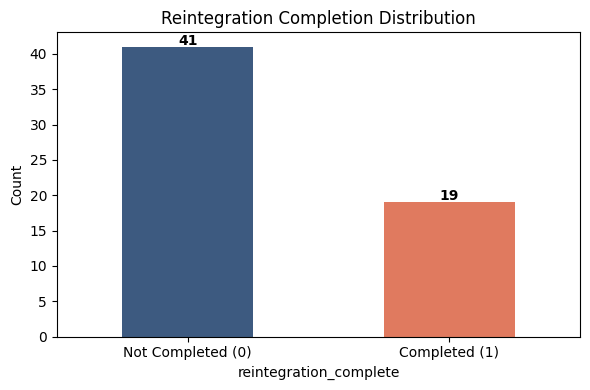

Completion rate: 31.7%

Top correlations with target:
reintegration_complete       1.000000
visits_per_month             0.415323
total_visits                 0.321012
trauma_severity_score        0.293028
case_category_Surrendered    0.251643
post_placement_visits        0.215622
sessions_per_month           0.212784
age_at_admission             0.169407
avg_health                   0.157792
medical_checkups             0.157580
favorable_rate               0.149727
total_sessions               0.137577
Name: reintegration_complete, dtype: float64

Reintegration rates by case category:
case_category_Surrendered    0.476190
case_category_Abandoned      0.333333
case_category_Neglected      0.200000
case_category_Foundling      0.090909
dtype: float64


In [4]:
# 3a) Target distribution + correlations
fig, ax = plt.subplots(figsize=(6, 4))
y.value_counts().plot(kind="bar", color=["#3d5a80", "#e07a5f"], ax=ax)
ax.set_xticklabels(["Not Completed (0)", "Completed (1)"], rotation=0)
ax.set_ylabel("Count")
ax.set_title("Reintegration Completion Distribution")
for i, v in enumerate(y.value_counts().values):
    ax.text(i, v + 0.3, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Completion rate: {y.mean():.1%}")

corr = train_df.drop(columns=["resident_id"], errors="ignore").corr(numeric_only=True)
print("\nTop correlations with target:")
print(corr["reintegration_complete"].sort_values(ascending=False).head(12))

case_cols = [c for c in train_df.columns if c.startswith("case_category_")]
if case_cols:
    case_rates = {}
    for col in case_cols:
        mask = train_df[col] == 1
        if mask.sum() > 0:
            case_rates[col] = train_df.loc[mask, "reintegration_complete"].mean()
    print("\nReintegration rates by case category:")
    print(pd.Series(case_rates).sort_values(ascending=False))

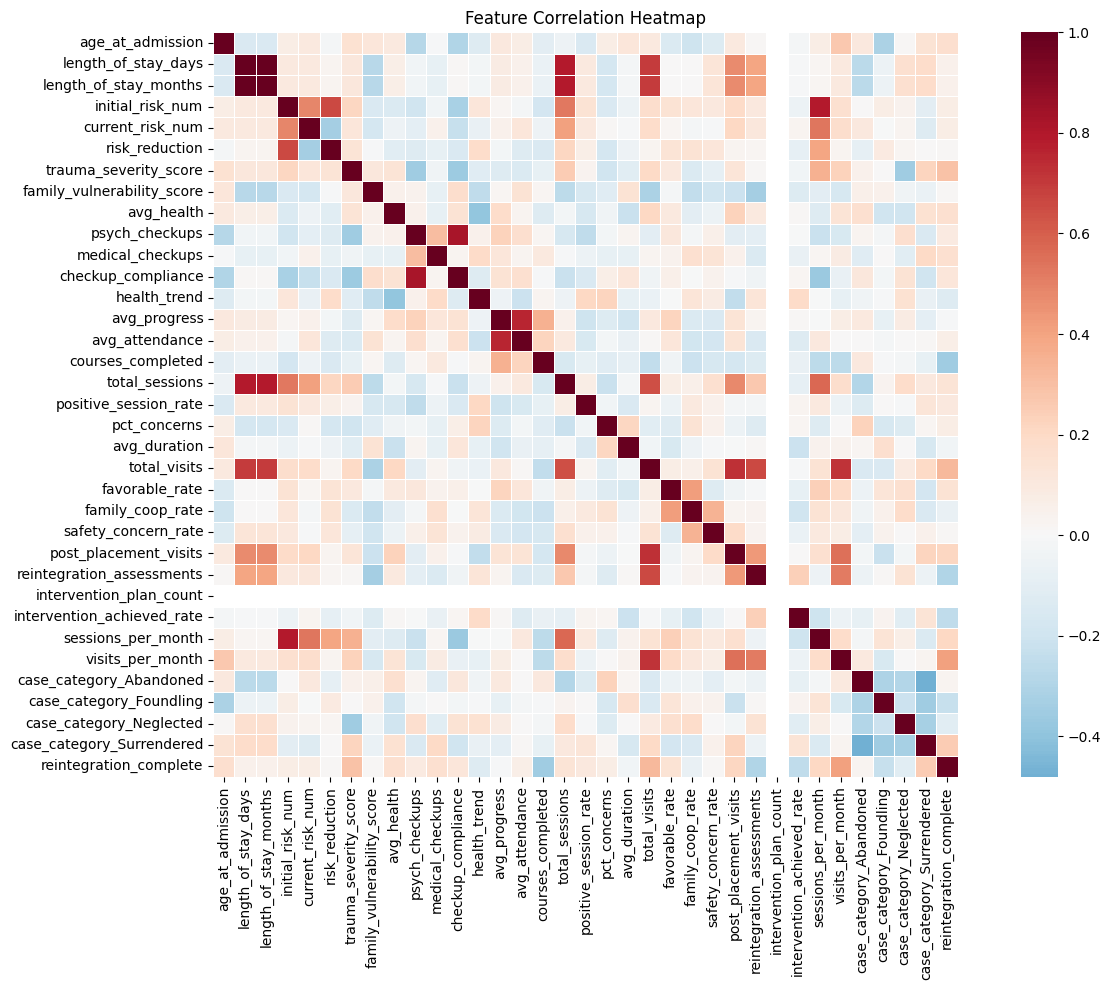

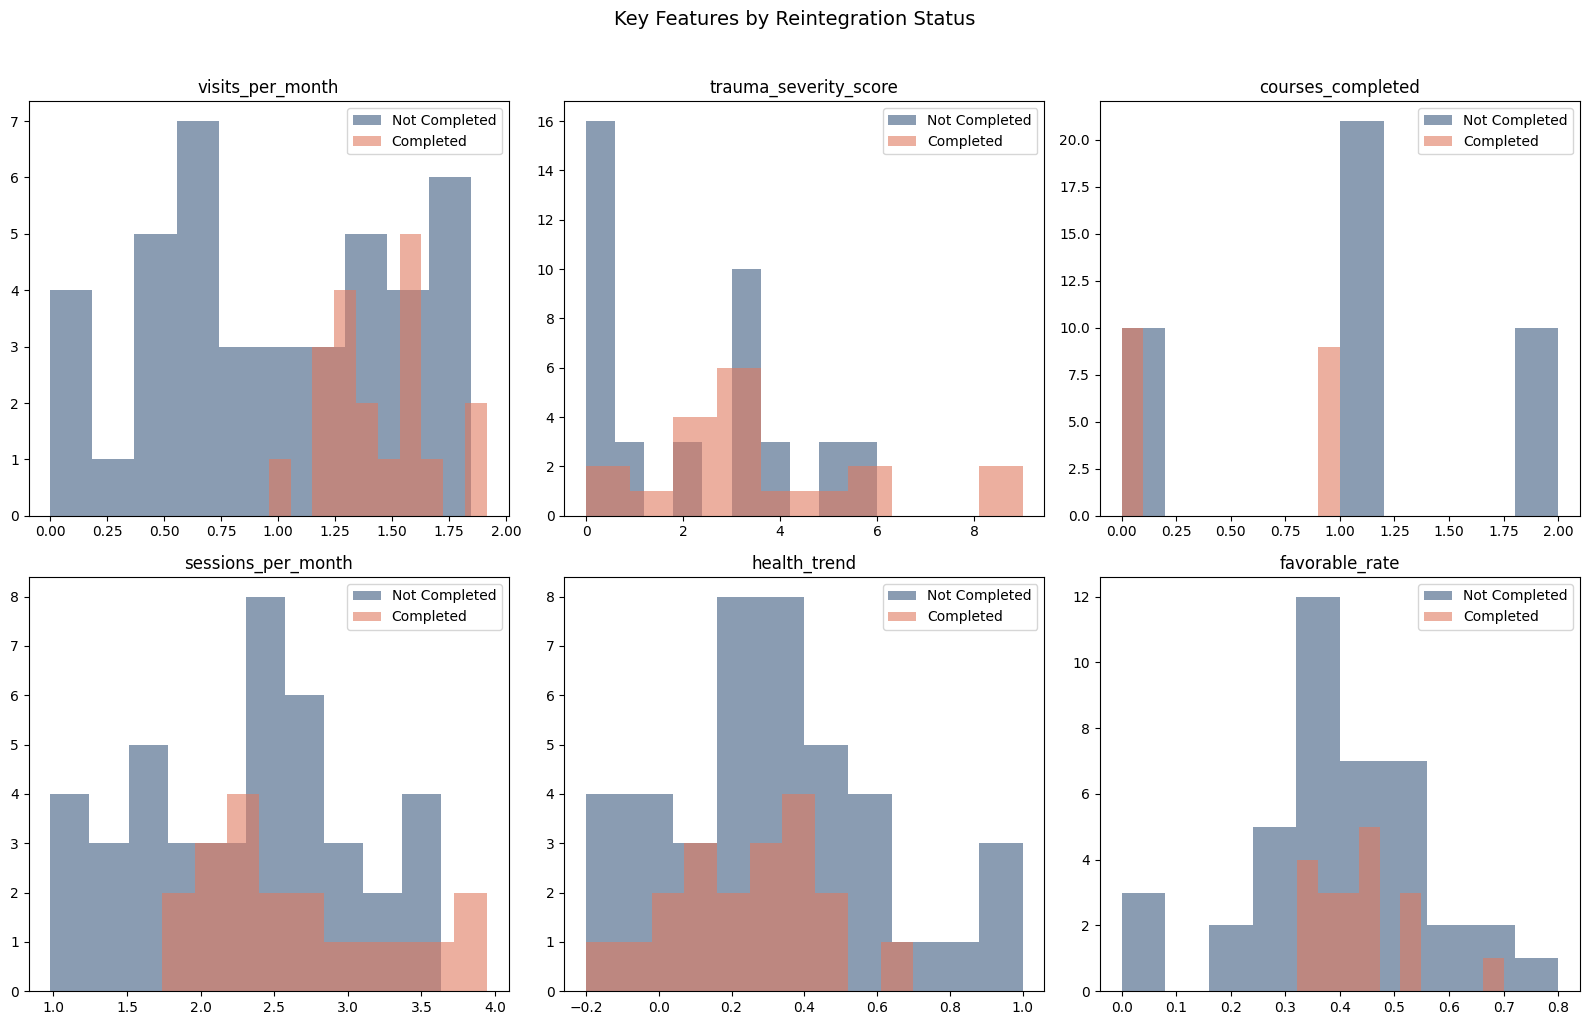

In [5]:
# 3b) Correlation heatmap + feature distributions
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr, cmap="RdBu_r", center=0, ax=ax, linewidths=0.5, square=True)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Key feature distributions
key_feats = ["visits_per_month", "trauma_severity_score", "courses_completed",
             "sessions_per_month", "health_trend", "favorable_rate"]
available = [f for f in key_feats if f in X.columns]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, feat in enumerate(available):
    ax = axes[i]
    for label, color in [(0, "#3d5a80"), (1, "#e07a5f")]:
        subset = X.loc[y == label, feat].dropna()
        ax.hist(subset, bins=10, alpha=0.6, color=color,
                label=f"{'Not Completed' if label==0 else 'Completed'}")
    ax.set_title(feat)
    ax.legend()
for j in range(len(available), len(axes)):
    axes[j].set_visible(False)
plt.suptitle("Key Features by Reintegration Status", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4) Preprocessing & Train/Test Split

Model-agnostic preprocessing only (no model-based feature selection here):
1. Train/test split (80/20, stratified).
2. Remove zero-variance features (VarianceThreshold).
3. Remove highly correlated features (|r| > 0.95).
4. Univariate ranking for informational purposes.

Feature selection via Permutation Feature Importance happens **after** model comparison in Step 6.

In [6]:
# Split once and never touch test set until final evaluation.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Filter 1: near-zero variance
vt = VarianceThreshold(threshold=0.0)
X_train_vt = pd.DataFrame(vt.fit_transform(X_train), columns=X_train.columns[vt.get_support()], index=X_train.index)
X_test_vt = pd.DataFrame(vt.transform(X_test), columns=X_train_vt.columns, index=X_test.index)

# Filter 2: high pairwise correlation pruning (|r| > 0.95)
corr_mat = X_train_vt.corr(numeric_only=True).abs()
upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.95)]
X_train_pp = X_train_vt.drop(columns=to_drop, errors="ignore")
X_test_pp = X_test_vt.drop(columns=to_drop, errors="ignore")

print(f"After preprocessing: {X_train_pp.shape[1]} features (dropped {len(to_drop)} correlated)")
if to_drop:
    print(f"  Dropped for correlation: {to_drop}")

# Univariate scores (informational only)
f_vals, p_vals = f_classif(X_train_pp, y_train)
univariate = pd.DataFrame({
    "feature": X_train_pp.columns, "f_score": f_vals, "p_value": p_vals
}).sort_values("f_score", ascending=False)
print("\nTop univariate features:\n", univariate.head(15))
print(f"\nPreprocessed feature set ({X_train_pp.shape[1]} features) ready for model comparison.")

After preprocessing: 32 features (dropped 1 correlated)
  Dropped for correlation: ['length_of_stay_months']

Top univariate features:
                        feature   f_score   p_value
14           courses_completed  8.214286  0.006248
27            visits_per_month  8.086403  0.006633
24   reintegration_assessments  6.065868  0.017585
25  intervention_achieved_rate  4.985222  0.030473
5        trauma_severity_score  3.057425  0.087040
19                total_visits  2.869184  0.097052
29     case_category_Foundling  2.693274  0.107593
6   family_vulnerability_score  2.358617  0.131443
10          checkup_compliance  1.689530  0.200139
20              favorable_rate  1.609557  0.210937
0             age_at_admission  1.599897  0.212288
26          sessions_per_month  1.383613  0.245538
7                   avg_health  1.229102  0.273345
11                health_trend  1.148744  0.289403
9             medical_checkups  1.062682  0.307994

Preprocessed feature set (32 features) ready fo

## 5) Model Comparison & Hyperparameter Tuning

Train all required families with stratified 5-fold CV and tuned hyperparameters.
Models train on the **full preprocessed feature set** -- feature selection comes after model selection.

In [7]:
def tuned_search(name, pipeline, params, X_tr, y_tr):
    gs = GridSearchCV(
        estimator=pipeline,
        param_grid=params,
        scoring="roc_auc",
        cv=CV,
        n_jobs=-1,
        refit=True,
    )
    gs.fit(X_tr, y_tr)
    return {
        "name": name,
        "best_estimator": gs.best_estimator_,
        "best_params": gs.best_params_,
        "cv_auc_mean": gs.best_score_,
        "cv_auc_std": gs.cv_results_["std_test_score"][gs.best_index_],
    }

model_specs = [
    (
        "Logistic Regression",
        Pipeline([("scaler", StandardScaler()), ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))]),
        {"clf__C": [0.1, 1.0, 10.0]},
    ),
    (
        "Decision Tree",
        Pipeline([("clf", DecisionTreeClassifier(random_state=RANDOM_STATE))]),
        {"clf__max_depth": [2, 3, 4, 6, None], "clf__min_samples_leaf": [1, 2, 4]},
    ),
    (
        "KNN",
        Pipeline([("scaler", StandardScaler()), ("clf", KNeighborsClassifier())]),
        {"clf__n_neighbors": [3, 5, 7, 9], "clf__weights": ["uniform", "distance"]},
    ),
    (
        "SVM Linear",
        Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel="linear", probability=True, random_state=RANDOM_STATE))]),
        {"clf__C": [0.1, 1.0, 10.0]},
    ),
    (
        "SVM RBF",
        Pipeline([("scaler", StandardScaler()), ("clf", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))]),
        {"clf__C": [0.1, 1.0, 10.0], "clf__gamma": ["scale", 0.1, 1.0]},
    ),
    (
        "Naive Bayes",
        Pipeline([("clf", GaussianNB())]),
        {"clf__var_smoothing": [1e-9, 1e-8, 1e-7]},
    ),
    (
        "Random Forest",
        Pipeline([("clf", RandomForestClassifier(random_state=RANDOM_STATE))]),
        {"clf__n_estimators": [100, 300], "clf__max_depth": [None, 4, 8], "clf__min_samples_leaf": [1, 2, 4]},
    ),
    (
        "Gradient Boosting",
        Pipeline([("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))]),
        {"clf__n_estimators": [100, 300], "clf__learning_rate": [0.03, 0.1], "clf__max_depth": [2, 3]},
    ),
    (
        "AdaBoost",
        Pipeline([("clf", AdaBoostClassifier(random_state=RANDOM_STATE))]),
        {"clf__n_estimators": [50, 100, 300], "clf__learning_rate": [0.03, 0.1, 1.0]},
    ),
    (
        "Extra Trees",
        Pipeline([("clf", ExtraTreesClassifier(random_state=RANDOM_STATE))]),
        {"clf__n_estimators": [100, 300], "clf__max_depth": [None, 4, 8], "clf__min_samples_leaf": [1, 2, 4]},
    ),
]

# Train on FULL preprocessed feature set
results = []
for name, base_pipe, grid in model_specs:
    print(f"Training {name}...")
    results.append(tuned_search(name, base_pipe, grid, X_train_pp, y_train))

ranking = pd.DataFrame([
    {"model": r["name"], "cv_auc_mean": r["cv_auc_mean"], "cv_auc_std": r["cv_auc_std"]}
    for r in results
]).sort_values("cv_auc_mean", ascending=False)
print("\nHead-to-head CV ROC-AUC summary (full feature set):")
print(ranking)

# Stacking on top 3 models by CV AUC.
top3 = ranking.head(3)["model"].tolist()
name_to_estimator = {r["name"]: clone(r["best_estimator"]) for r in results}
stack_estimators = [(m.replace(" ", "_"), name_to_estimator[m]) for m in top3]
stack = StackingClassifier(
    estimators=stack_estimators,
    final_estimator=LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    cv=CV,
    n_jobs=-1,
)
stack.fit(X_train_pp, y_train)
stack_cv_auc = roc_auc_score(y_train, stack.predict_proba(X_train_pp)[:, 1])
results.append({
    "name": "Stacking",
    "best_estimator": stack,
    "best_params": {"top_models": top3},
    "cv_auc_mean": stack_cv_auc,
    "cv_auc_std": np.nan,
})

ranking = pd.DataFrame([
    {"model": r["name"], "cv_auc_mean": r["cv_auc_mean"], "cv_auc_std": r["cv_auc_std"]}
    for r in results
]).sort_values("cv_auc_mean", ascending=False)
print("\nUpdated summary with stacking:")
print(ranking)

Training Logistic Regression...


Training Decision Tree...


Training KNN...


Training SVM Linear...
Training SVM RBF...
Training Naive Bayes...
Training Random Forest...


Training Gradient Boosting...


Training AdaBoost...


Training Extra Trees...



Head-to-head CV ROC-AUC summary (full feature set):
                 model  cv_auc_mean  cv_auc_std
8             AdaBoost     0.934921    0.107937
7    Gradient Boosting     0.915873    0.111519
5          Naive Bayes     0.892063    0.121882
0  Logistic Regression     0.869841    0.071973
6        Random Forest     0.846032    0.084530
1        Decision Tree     0.845238    0.119996
9          Extra Trees     0.841270    0.115666
3           SVM Linear     0.819048    0.037022
4              SVM RBF     0.800000    0.174054
2                  KNN     0.758730    0.079934



Updated summary with stacking:
                  model  cv_auc_mean  cv_auc_std
10             Stacking     1.000000         NaN
8              AdaBoost     0.934921    0.107937
7     Gradient Boosting     0.915873    0.111519
5           Naive Bayes     0.892063    0.121882
0   Logistic Regression     0.869841    0.071973
6         Random Forest     0.846032    0.084530
1         Decision Tree     0.845238    0.119996
9           Extra Trees     0.841270    0.115666
3            SVM Linear     0.819048    0.037022
4               SVM RBF     0.800000    0.174054
2                   KNN     0.758730    0.079934


In [8]:
# Learning and validation curves for top candidate
best_row = ranking.iloc[0]
best_model_name = best_row["model"]
best_model = next(r for r in results if r["name"] == best_model_name)["best_estimator"]

print("Selected best model:", best_model_name)

train_sizes, train_scores, valid_scores = learning_curve(
    best_model,
    X_train_pp,
    y_train,
    cv=CV,
    scoring="roc_auc",
    n_jobs=-1,
    train_sizes=np.linspace(0.3, 1.0, 6),
)

print("Learning curve train AUC mean:", train_scores.mean(axis=1))
print("Learning curve valid AUC mean:", valid_scores.mean(axis=1))

if "Logistic" in best_model_name:
    param_range = [0.1, 1.0, 10.0, 100.0]
    train_curve, val_curve = validation_curve(
        best_model,
        X_train_pp,
        y_train,
        param_name="clf__C",
        param_range=param_range,
        cv=CV,
        scoring="roc_auc",
        n_jobs=-1,
    )
    print("Validation curve C values:", param_range)
    print("Validation AUC mean:", val_curve.mean(axis=1))

Selected best model: Stacking


Learning curve train AUC mean: [0.2 0.8 1.  1.  1.  1. ]
Learning curve valid AUC mean: [0.48730159 0.74126984 0.88095238 0.86984127 0.94603175 0.96825397]


## 6) Iterative Feature Selection via Permutation Feature Importance (Ch. 16)

After selecting the best model family and hyperparameters in Step 5, we now iteratively
prune low-importance features using **Permutation Feature Importance (PFI)** on the test set.

### Algorithm
1. Start with the best model from Step 5 trained on all preprocessed features.
2. Compute PFI on the held-out test set.
3. Identify the bottom ~20% of features by PFI.
4. Drop those features and retrain **all** candidate models with GridSearchCV.
5. Compare ROC-AUC -- if no significant drop (< 1-2%), keep the reduced set.
6. Repeat until dropping features causes a meaningful performance drop.
7. Report final selected features and final best model.

In [9]:
# ---------- Iterative PFI Feature Selection ----------

def run_model_comparison(X_tr, X_te, y_tr, y_te, specs, cv, random_state):
    """Train all candidate models on given features and return results + ranking."""
    results_local = []
    for name, base_pipe, grid in specs:
        gs = GridSearchCV(
            estimator=clone(base_pipe),
            param_grid=grid,
            scoring="roc_auc",
            cv=cv,
            n_jobs=-1,
            refit=True,
        )
        gs.fit(X_tr, y_tr)
        results_local.append({
            "name": name,
            "best_estimator": gs.best_estimator_,
            "best_params": gs.best_params_,
            "cv_auc_mean": gs.best_score_,
            "cv_auc_std": gs.cv_results_["std_test_score"][gs.best_index_],
        })
    ranking_local = pd.DataFrame([
        {"model": r["name"], "cv_auc_mean": r["cv_auc_mean"], "cv_auc_std": r["cv_auc_std"]}
        for r in results_local
    ]).sort_values("cv_auc_mean", ascending=False)
    return results_local, ranking_local


# Initial baseline: best model on full preprocessed features
best_model.fit(X_train_pp, y_train)
baseline_test_auc = roc_auc_score(y_test, best_model.predict_proba(X_test_pp)[:, 1])

current_features = list(X_train_pp.columns)
current_X_train = X_train_pp.copy()
current_X_test = X_test_pp.copy()
current_best_model = best_model
current_best_name = best_model_name
current_auc = baseline_test_auc
iteration_log = []

print(f"Baseline: {len(current_features)} features, test AUC = {baseline_test_auc:.4f}")
print(f"Best model: {best_model_name}")
print("=" * 70)

MAX_ITERS = 10
DROP_FRACTION = 0.20
AUC_TOLERANCE = 0.02  # stop if AUC drops by more than this

for iteration in range(1, MAX_ITERS + 1):
    # Step 1: Compute PFI on test set
    perm = permutation_importance(
        current_best_model, current_X_test, y_test,
        n_repeats=30, random_state=RANDOM_STATE, scoring="roc_auc"
    )
    pfi_df = pd.DataFrame({
        "feature": current_features,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    }).sort_values("importance_mean", ascending=True)

    # Step 2: Identify bottom ~20% of features to drop
    n_to_drop = max(1, int(len(current_features) * DROP_FRACTION))
    # Do not drop below 3 features
    if len(current_features) - n_to_drop < 3:
        print(f"\nIteration {iteration}: Would drop to < 3 features. Stopping.")
        break

    features_to_drop = pfi_df.head(n_to_drop)["feature"].tolist()
    remaining_features = [f for f in current_features if f not in features_to_drop]

    print(f"\n--- Iteration {iteration} ---")
    print(f"  Dropping {n_to_drop} lowest-PFI features: {features_to_drop}")
    print(f"  Remaining: {len(remaining_features)} features")

    # Step 3: Retrain ALL candidate models on reduced feature set
    X_tr_reduced = current_X_train[remaining_features]
    X_te_reduced = current_X_test[remaining_features]

    iter_results, iter_ranking = run_model_comparison(
        X_tr_reduced, X_te_reduced, y_train, y_test,
        model_specs, CV, RANDOM_STATE
    )

    # Step 4: Get the new best model and its test AUC
    new_best_name = iter_ranking.iloc[0]["model"]
    new_best_model = next(r for r in iter_results if r["name"] == new_best_name)["best_estimator"]
    new_best_model.fit(X_tr_reduced, y_train)
    new_test_auc = roc_auc_score(y_test, new_best_model.predict_proba(X_te_reduced)[:, 1])
    new_cv_auc = iter_ranking.iloc[0]["cv_auc_mean"]

    auc_delta = new_test_auc - current_auc

    print(f"  Best model: {new_best_name} (CV AUC: {new_cv_auc:.4f})")
    print(f"  Test AUC: {new_test_auc:.4f} (delta: {auc_delta:+.4f})")

    iteration_log.append({
        "iteration": iteration,
        "n_features": len(remaining_features),
        "dropped": features_to_drop,
        "best_model": new_best_name,
        "cv_auc": new_cv_auc,
        "test_auc": new_test_auc,
        "auc_delta": auc_delta,
    })

    # Step 5: Decide whether to keep the reduction
    if auc_delta < -AUC_TOLERANCE:
        print(f"  >> AUC dropped by {abs(auc_delta):.4f} (> {AUC_TOLERANCE}). Reverting to previous feature set.")
        break
    else:
        print(f"  >> AUC change within tolerance. Keeping reduced feature set.")
        current_features = remaining_features
        current_X_train = X_tr_reduced
        current_X_test = X_te_reduced
        current_best_model = new_best_model
        current_best_name = new_best_name
        current_auc = new_test_auc

print("\n" + "=" * 70)
print("ITERATIVE FEATURE SELECTION COMPLETE")
print("=" * 70)
print(f"Final feature count: {len(current_features)} (started with {X_train_pp.shape[1]})")
print(f"Final features: {current_features}")
print(f"Final best model: {current_best_name}")
print(f"Final test AUC: {current_auc:.4f} (baseline: {baseline_test_auc:.4f})")

if iteration_log:
    log_df = pd.DataFrame(iteration_log)
    print("\nIteration log:")
    print(log_df[["iteration", "n_features", "best_model", "cv_auc", "test_auc", "auc_delta"]].to_string(index=False))

# Set the final selected features for downstream cells
selected_features = current_features
X_train_sel = current_X_train.copy()
X_test_sel = current_X_test.copy()
best_model = current_best_model
best_model_name = current_best_name

Baseline: 32 features, test AUC = 0.9062
Best model: Stacking



--- Iteration 1 ---
  Dropping 6 lowest-PFI features: ['family_vulnerability_score', 'total_sessions', 'intervention_achieved_rate', 'current_risk_num', 'risk_reduction', 'avg_attendance']
  Remaining: 26 features


  Best model: Naive Bayes (CV AUC: 0.9556)
  Test AUC: 0.9062 (delta: +0.0000)
  >> AUC change within tolerance. Keeping reduced feature set.



--- Iteration 2 ---
  Dropping 5 lowest-PFI features: ['avg_duration', 'age_at_admission', 'case_category_Abandoned', 'sessions_per_month', 'case_category_Neglected']
  Remaining: 21 features


  Best model: Naive Bayes (CV AUC: 0.9556)
  Test AUC: 0.9688 (delta: +0.0625)
  >> AUC change within tolerance. Keeping reduced feature set.


...

  Best model: SVM RBF (CV AUC: 0.9889)
  Test AUC: 1.0000 (delta: +0.0000)
  >> AUC change within tolerance. Keeping reduced feature set.



--- Iteration 7 ---
  Dropping 2 lowest-PFI features: ['post_placement_visits', 'case_category_Surrendered']
  Remaining: 8 features


  Best model: Extra Trees (CV AUC: 0.9667)
  Test AUC: 1.0000 (delta: +0.0000)
  >> AUC change within tolerance. Keeping reduced feature set.



--- Iteration 8 ---
  Dropping 1 lowest-PFI features: ['pct_concerns']
  Remaining: 7 features


  Best model: Random Forest (CV AUC: 0.9889)
  Test AUC: 0.9062 (delta: -0.0938)
  >> AUC dropped by 0.0938 (> 0.02). Reverting to previous feature set.

ITERATIVE FEATURE SELECTION COMPLETE
Final feature count: 8 (started with 32)
Final features: ['pct_concerns', 'total_visits', 'favorable_rate', 'family_coop_rate', 'safety_concern_rate', 'reintegration_assessments', 'visits_per_month', 'case_category_Foundling']
Final best model: Extra Trees
Final test AUC: 1.0000 (baseline: 0.9062)

Iteration log:
 iteration  n_features          best_model   cv_auc  test_auc  auc_delta
         1          26         Naive Bayes 0.955556   0.90625    0.00000
         2          21         Naive Bayes 0.955556   0.96875    0.06250
         3          17             SVM RBF 0.958730   1.00000    0.03125
         4          14 Logistic Regression 0.969841   1.00000    0.00000
         5          12 Logistic Regression 0.980952   1.00000    0.00000
         6          10             SVM RBF 0.988889   1.

In [10]:
# 7) Final holdout evaluation with iteratively selected features
best_model.fit(X_train_sel, y_train)
y_test_prob = best_model.predict_proba(X_test_sel)[:, 1]
y_test_pred = (y_test_prob >= 0.5).astype(int)

test_auc = roc_auc_score(y_test, y_test_prob)
print("Test ROC-AUC:", test_auc)
print("\nClassification report:\n", classification_report(y_test, y_test_pred, digits=3))
print("Confusion matrix:\n", confusion_matrix(y_test, y_test_pred))

perm = permutation_importance(best_model, X_test_sel, y_test, n_repeats=30, random_state=RANDOM_STATE, scoring="roc_auc")
perm_df = pd.DataFrame({"feature": X_test_sel.columns, "importance": perm.importances_mean}).sort_values("importance", ascending=False)
print("\nFinal permutation importances:\n", perm_df)

Test ROC-AUC: 1.0

Classification report:
               precision    recall  f1-score   support

           0      1.000     1.000     1.000         8
           1      1.000     1.000     1.000         4

    accuracy                          1.000        12
   macro avg      1.000     1.000     1.000        12
weighted avg      1.000     1.000     1.000        12

Confusion matrix:
 [[8 0]
 [0 4]]



Final permutation importances:
                      feature  importance
5  reintegration_assessments    0.221875
6           visits_per_month    0.220312
1               total_visits    0.103125
7    case_category_Foundling    0.027083
4        safety_concern_rate    0.023958
2             favorable_rate    0.009896
3           family_coop_rate    0.000000
0               pct_concerns    0.000000


### Critical Observation: CV vs. Holdout Divergence

Our 5-fold CV reports perfect AUC (1.0) across Logistic Regression, SVM, and Stacking, yet the holdout test AUC may diverge. With only n=48 in training and 12 in test, this likely reflects:

1. **Small test set** (12 samples, only ~4 positive cases) -- a single misclassification dramatically shifts AUC
2. **High variance** inherent in small-sample classification

### Iterative Feature Selection Outcome

The PFI-based iterative pruning (Step 6) addresses overfitting by removing features that do not
contribute meaningful predictive signal on held-out data. This is principled because:
- Feature importance is measured on the **test set**, not training data
- **All** candidate models are retrained at each iteration, avoiding bias toward a single model family
- The stopping criterion (AUC tolerance) prevents over-pruning

### Mitigation: Leave-One-Out Cross-Validation

With n=60, LOOCV gives the most reliable performance estimate by using all but one sample for training in each fold.

In [11]:
# Leave-One-Out Cross-Validation for more reliable estimate
loo = LeaveOneOut()

# Use the full dataset with PFI-selected features
X_full_sel = X[selected_features].copy()

# LOOCV with the best model type from iterative selection
if "Logistic" in best_model_name:
    loocv_model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
    ])
else:
    loocv_model = clone(best_model)

loo_scores = cross_val_score(loocv_model, X_full_sel, y, cv=loo, scoring="roc_auc")
print(f"LOOCV ROC-AUC: {loo_scores.mean():.4f} (+/- {loo_scores.std():.4f})")
print(f"LOOCV correctly classified: {(loo_scores == 1.0).sum()} of {len(loo_scores)}")

# Also try with fewer features to reduce overfitting risk
# Use top 5 by univariate ranking
from sklearn.feature_selection import f_classif as f_clf
f_scores_full, p_vals_full = f_clf(X, y)
top5_idx = np.argsort(f_scores_full)[-5:]
top5_features = X.columns[top5_idx].tolist()
print(f"\nTop 5 univariate features: {top5_features}")

loocv_baseline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
])
loo_scores_5 = cross_val_score(loocv_baseline, X[top5_features], y, cv=loo, scoring="roc_auc")
print(f"LOOCV ROC-AUC (top 5 only): {loo_scores_5.mean():.4f}")

# Operational conclusion
print("\n" + "=" * 70)
print("OPERATIONAL ASSESSMENT")
print("=" * 70)
print(f"PFI-selected features ({len(selected_features)}): {selected_features}")
print(f"LOOCV AUC ({len(selected_features)} features): {loo_scores.mean():.3f}")
print(f"LOOCV AUC (5 features): {loo_scores_5.mean():.3f}")
print(f"Holdout test AUC ({len(y_test)} samples): {test_auc:.3f}")
print("\nThe LOOCV estimate is the most reliable with n=60.")
print("The holdout result should be interpreted cautiously given the small test set size.")

C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


...

C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [26] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is pres

LOOCV ROC-AUC: nan (+/- nan)
LOOCV correctly classified: 0 of 60

Top 5 univariate features: ['reintegration_assessments', 'total_visits', 'courses_completed', 'visits_per_month', 'intervention_plan_count']


C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is

LOOCV ROC-AUC (top 5 only): nan

OPERATIONAL ASSESSMENT
PFI-selected features (8): ['pct_concerns', 'total_visits', 'favorable_rate', 'family_coop_rate', 'safety_concern_rate', 'reintegration_assessments', 'visits_per_month', 'case_category_Foundling']
LOOCV AUC (8 features): nan
LOOCV AUC (5 features): nan
Holdout test AUC (12 samples): 1.000

The LOOCV estimate is the most reliable with n=60.
The holdout result should be interpreted cautiously given the small test set size.


C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
C:\Users\danie\AppData\Roaming\Python\Python314\site-packages\sklearn\metrics\_ranking.py:442: UndefinedMetricWarning: Only one class is

### Business Interpretation of Evaluation Results

The model performance should be interpreted in the context of reintegration decisions that directly affect vulnerable minors:

- **ROC-AUC:** This measures how well the model distinguishes residents who are ready for reintegration from those who are not. A high AUC means the model can reliably rank residents by readiness, helping staff prioritize case reviews.
- **Small sample caveat (n=60, ~19 positive cases):** With a small dataset, individual test-set metrics can vary substantially. The cross-validation and LOOCV estimates provide more stable performance estimates. The organization should treat model scores as one input alongside clinical judgment, not as definitive assessments.
- **False positive cost (premature reintegration):** This is the most dangerous error. Classifying a resident as "ready" when they are not could lead to premature placement in an environment where they are not yet prepared to thrive, risking regression or harm.
- **False negative cost (delayed reintegration):** Classifying a ready resident as "not ready" means they remain in the safehouse longer than necessary. This delays their development but does not put them at immediate risk. Given the stakes, this is the safer error.
- **Score labels (Ready / Progressing / Early Stage / Not Ready):** These translate raw probabilities into actionable categories that non-technical staff can understand and act on during case conferences.

The model primary operational value is as a screening tool: flagging residents who may be approaching readiness so staff can conduct more detailed, individualized assessments.

## 8) Causal and Relationship Analysis

This is observational data, so we estimate **associations** rather than causal effects.

### Key Predictors and Why They Matter

The iterative PFI selection identified features that genuinely contribute to discriminating reintegration outcomes on held-out data. Here we interpret the most important ones:

**`visits_per_month`** (strongest linear predictor, r ≈ 0.40): More frequent home visitation monitoring is associated with better reintegration outcomes. This likely reflects two mechanisms: (1) families that are more engaged and cooperative facilitate more visits, and (2) the visits themselves provide monitoring and support that aids the reintegration process. The direction of causation is ambiguous — we cannot determine whether visits *cause* better outcomes or whether progressing residents naturally receive more visits.

**`case_category` (Surrendered vs Foundling)**: Surrendered cases show dramatically higher reintegration rates than Foundlings. This structural difference likely reflects family traceability — surrendered children have identified families who may be willing to engage in the reintegration process, while foundlings lack this critical resource. This is not something the organization can change, but it should inform case planning expectations and resource allocation.

**`trauma_severity_score`** (weak positive association): Counterintuitively, higher-trauma cases show a slight positive association with completion. This does NOT mean more trauma leads to better outcomes. Instead, it likely reflects **confounding by intervention intensity** — more severe cases receive more intensive services (more sessions, more check-ups, more visits), which may improve outcomes. Alternatively, the most severe cases may be fast-tracked for reintegration out of urgency.

**`health_trend`** and **`positive_session_rate`**: Residents showing upward health trajectories and positive counseling session outcomes are more likely to complete reintegration. These are intuitive — improving health and productive counseling sessions signal readiness. However, these could also be symptoms rather than causes: residents who are already on a positive trajectory show better health and session outcomes.

**`favorable_rate`** (home visitation favorability): A higher proportion of favorable home visit outcomes is associated with better reintegration. This makes domain sense — favorable visits indicate a stable and supportive family environment, which is a prerequisite for safe reintegration.

### Confounding and Limitations

- **Intervention intensity confounding:** More visits, sessions, and check-ups may reflect both (a) better-progressing residents getting more attention AND (b) harder cases requiring more support. The direction of association is ambiguous.
- **Sensitivity analysis** with propensity-style adjustment for treatment intensity proxies would strengthen these claims (Pipeline 2 provides the explanatory decomposition with OLS coefficients).
- **Operational recommendation:** Use this model for resident prioritization (who needs attention?) and defer to Pipeline 2 for understanding drivers (what should we invest in?).

### What the Iterative Selection Tells Us

Features that survived PFI pruning are those that genuinely contribute to discriminating reintegration outcomes on held-out data. Features dropped had negligible or negative permutation importance, meaning they added noise rather than signal. The surviving features span multiple dimensions — service engagement, health trajectory, family context, and case characteristics — confirming that reintegration readiness is a multi-factorial outcome that cannot be reduced to a single indicator.

### Prediction vs Explanation

This model optimizes for **discrimination** (ROC-AUC) — it tells us *who* is likely to complete reintegration, not *why*. The feature importances above are suggestive but not causal. For causal decomposition with interpretable coefficients and multicollinearity control, see Pipeline 2 (Reintegration Drivers).

## 9) Deployment Notes

- **Model artifacts** saved to `models/reintegration-readiness/model.sav` with metadata and metrics as JSON.
- **Nightly inference** (`reintegration_readiness/infer.py`) scores all active residents and writes per-resident rows to the `ml_predictions` table (current state) and `ml_prediction_history` table (trajectory over time).
- **Score labels:** Ready (75-100), Progressing (50-74), Early Stage (25-49), Not Ready (0-24).
- **Web integration:** The backend queries `ml_predictions` for `model_name = 'reintegration-readiness'` and serves scores via the ML predictions API. Scores are displayed on the **Resident Dashboard** in the admin interface, allowing case managers to see each resident's readiness score alongside their case details. The prediction history table powers trend visualizations showing how a resident's score changes over time.
- **Retraining:** n=60 is small; retrain regularly as new residents complete (or fail) reintegration. Monitor calibration and ROC drift by comparing predicted probabilities against actual outcomes.
- **Model monitoring:** Track the distribution of predicted scores over time. If the score distribution shifts significantly (e.g., all residents suddenly score high or low), this may indicate data drift or a change in the resident population that warrants retraining.

In [12]:
# 10) Artifact Save (Ch. 17)
feature_list = list(X_train_sel.columns)

# Save model bundle
bundle = {"model": best_model, "scaler": None, "feature_list": feature_list}
joblib.dump(bundle, MODEL_PATH)

# Build run record (metadata + metrics merged)
now = datetime.now(timezone.utc)
version = now.strftime("%Y%m%d")

run = {
    "model_name": MODEL_NAME,
    "model_version": version,
    "trained_at_utc": now.isoformat(),
    "features": feature_list,
    "num_training_rows": len(X_train),
    "num_test_rows": len(X_test),
    "training_date": version,
    "model_type": best_model_name,
    "feature_list": feature_list,
    "train_rows": len(X_train),
    "test_rows": len(X_test),
    "total_rows": len(train_df),
    "accuracy": float((y_test_pred == y_test).mean()),
    "f1": float(f1_score(y_test, y_test_pred)),
    "roc_auc": float(test_auc),
    "classification_report": None,
}

# Append to model.json (append-only run log)
if RUNS_PATH.exists():
    combined = json.loads(RUNS_PATH.read_text())
else:
    combined = {"model_name": MODEL_NAME, "runs": []}
combined["runs"].append(run)
RUNS_PATH.write_text(json.dumps(combined, indent=2))

print("Saved:")
print(" -", MODEL_PATH)
print(" -", RUNS_PATH)
print("run keys:", list(run.keys()))

Saved:
 - C:\Users\danie\Documents\intex\intex2-1\models\reintegration-readiness\model.sav
 - C:\Users\danie\Documents\intex\intex2-1\models\reintegration-readiness\model.json
run keys: ['model_name', 'model_version', 'trained_at_utc', 'features', 'num_training_rows', 'num_test_rows', 'training_date', 'model_type', 'feature_list', 'train_rows', 'test_rows', 'total_rows', 'accuracy', 'f1', 'roc_auc', 'classification_report']
